In [1]:
import os

os.chdir('..')

## Loading the Dataset:

In this section the pointcloud is loaded. The SIREN paper suggests normalizing the point coordinates as periodic activations implicitly expect a bounded input. 

In [2]:
import open3d as o3d
import numpy as np
import torch
import matplotlib.pyplot as plt
import src.model.SIREN as si
from src.model.training import train
import src.loss.SDF_loss as loss


pcd = o3d.io.read_point_cloud("data/pointclouds/Armadillo/Armadillo.ply")

points = np.asarray(pcd.points)   # (N, 3)

print('Points before normalization:\n', points)

points /= np.max(np.linalg.norm(points, axis=1))
print('\n Points after:\n', points)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Points before normalization:
 [[  5.8945775   11.78840065  27.28323936]
 [-53.32511139  67.10436249 -57.45013046]
 [  3.75048876  16.50540161  29.45401955]
 ...
 [ -0.53707075  -6.22242689  42.90413666]
 [-49.76054001 -52.08040619   1.24506998]
 [-57.97610855  62.83114624 -50.2011261 ]]

 Points after:
 [[ 0.05403114  0.10805537  0.25008487]
 [-0.48879106  0.61509506 -0.526602  ]
 [ 0.0343779   0.15129256  0.26998277]
 ...
 [-0.00492292 -0.05703629  0.39326985]
 [-0.45611732 -0.47738179  0.01141262]
 [-0.53142324  0.57592571 -0.46015584]]


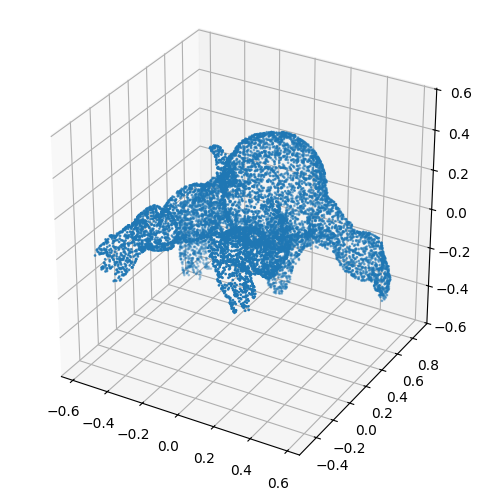

In [3]:
idx = np.random.choice(len(points), 10000, replace=False)
pts = points[idx]
x, y, z = pts[:,0], pts[:,1], pts[:,2]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, s=1)
ax.set_box_aspect([1, 1, 1])

plt.show()


## Defining the Model

In this cell we will define the SIREN model. This particular INR uses sine activations for nonlinearity and is supposed to capture more information given the underlying data when compared to a model that uses ReLU activations. This way, a good INR accuracy can be achieved with fewer neurons.

In [4]:
size_per_layer = 128
model = si.SIRENSDF(hidden_dim=size_per_layer, num_hidden_layers=4)
model_loss = loss.Loss(lambda_surface=1, lambda_eikonal=0.1, lambda_normal=0, normal_present=False, lambda_twd=1e-4, k=int(size_per_layer/5), model=model) # optional normal loss if normals contained in the pointcloud
optimizer = torch.optim.Adam(model.parameters())
model.neuron_counts()


Neuron counts per layer:
----------------------------------------
Hidden layer  0:  128 neurons
Hidden layer  1:  128 neurons
Hidden layer  2:  128 neurons
Hidden layer  3:  128 neurons
Hidden layer  4:  128 neurons
Final layer    :    1 neurons


## Model training



In [ ]:
train(epochs=1000, data=points, no_surface=1024, no_off_surface=2048, model=model, loss=model_loss, optimizer=optimizer, prune=False)

/home/nikola/miniconda3/envs/test/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Step 0 | Loss 0.1041623055934906
Step 10 | Loss 0.02782502770423889
Step 20 | Loss 0.02479655295610428
Step 30 | Loss 0.025809086859226227
Step 40 | Loss 0.026175394654273987
Step 50 | Loss 0.02667064592242241
Step 60 | Loss 0.027754349634051323
Step 70 | Loss 0.0273849219083786
Step 80 | Loss 0.02896447479724884
Step 90 | Loss 0.03029739111661911
Pruned 104 neurons.
Added 26 frequencies to the embedding layer.
Step 100 | Loss 0.031032776460051537
Step 110 | Loss 0.026133431121706963
Step 120 | Loss 0.026665277779102325
Step 130 | Loss 0.02748224511742592
Step 140 | Loss 0.02700924314558506
Step 150 | Loss 0.025880996137857437
Step 160 | Loss 0.026765629649162292
Step 170 | Loss 0.026666082441806793
Step 180 | Loss 0.027114808559417725
Step 190 | Loss 0.02628181129693985
Step 200 | Loss 0.026323646306991577
Step 210 | Loss 0.02653084322810173
Step 220 | Loss 0.028388306498527527
Step 230 | Loss 0.025811048224568367
Step 240 | Loss 0.02543046697974205
Step 250 | Loss 0.02659448236227035

#### Model size after pruning

In [6]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  154 neurons
Hidden layer  1:  102 neurons
Hidden layer  2:  102 neurons
Hidden layer  3:  102 neurons
Hidden layer  4:  102 neurons
Final layer    :    1 neurons


In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Sample a few surface points and check their SDF values
test_points = points[:10]  # First 10 points
test_tensor = torch.from_numpy(test_points).float().to(device)
with torch.no_grad():
    sdf_values = model(test_tensor)
print("SDF values for surface points:")
print(sdf_values)
print("Mean absolute SDF:", torch.abs(sdf_values).mean().item())

SDF values for surface points:
tensor([[-0.0016],
        [-0.0012],
        [-0.0021],
        [-0.0011],
        [-0.0022],
        [-0.0019],
        [-0.0004],
        [-0.0006],
        [-0.0026],
        [-0.0029]], device='cuda:0')
Mean absolute SDF: 0.0016672158380970359


In [8]:
import src.mesh_extraction.marching_cubes as marching_cubes
marching_cubes.write_obj("armadillo_mesh_16.obj", model=model, resolution=16, level=0.0)
marching_cubes.write_obj("armadillo_mesh_32.obj", model=model, resolution=32, level=0.0)
marching_cubes.write_obj("armadillo_mesh_48.obj", model=model, resolution=48, level=0.0)